# Fine-tuning BERT
**Modelo base:** `bert-base-uncased`  
**Tarea:** Clasificación multiclase (5 modelos LLM)  
**Input:** `text` original
**Loss:** CrossEntropyLoss

---
## 0. Setup e Imports

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

MODEL_SHORT = {
    'x-ai/grok-3-mini':                 'Grok-3-mini',
    'openai/gpt-4.1-nano':              'GPT-4.1-nano',
    'mistralai/mixtral-8x7b-instruct':  'Mixtral-8x7b',
    'meta-llama/llama-3.2-1b-instruct': 'Llama-3.2-1b',
    'google/gemini-2.5-flash-lite':     'Gemini-2.5-lite',
}

print('Setup completado')

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
VRAM disponible: 8.6 GB
Setup completado


---
## 1. Carga del Dataset

In [13]:
DATA_PATH = '../datasets/dataset_preprocesado.csv'
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df_raw['model_short'] = df_raw['model'].map(MODEL_SHORT)

# Usamos text original — BERT tiene su propio tokenizador
df_raw['text'] = df_raw['text'].fillna('').astype(str)

print(f'Filas: {len(df_raw):,} | Clases: {df_raw["model_short"].nunique()}')
print(df_raw['model_short'].value_counts())

Filas: 45,481 | Clases: 5
model_short
Grok-3-mini        9111
GPT-4.1-nano       9103
Mixtral-8x7b       9101
Llama-3.2-1b       9092
Gemini-2.5-lite    9074
Name: count, dtype: int64


In [14]:
df = df_raw.drop_duplicates(subset=['question', 'model_short'], keep='first')
df = df.drop_duplicates(subset=['text_clean'], keep='first')

# Aseguramos que no haya nulos en text_clean
df['text_clean'] = df['text_clean'].fillna('')

print(f"Filas originales: {len(df):,} | Tras limpieza: {len(df):,}")

Filas originales: 19,421 | Tras limpieza: 19,421


In [15]:
topic_reservado = 'space exploration'
print(f"Tema reservado para Test (OOD): '{topic_reservado}'")

df_trainval = df[df['topic'] != topic_reservado].copy()
df_test     = df[df['topic'] == topic_reservado].copy()

print(f"Train+Val: {len(df_trainval):,} | Test OOD: {len(df_test):,}")

Tema reservado para Test (OOD): 'space exploration'
Train+Val: 17,842 | Test OOD: 1,579


---
## 2. Hiperparámetros
> BERT con GPU: batch size 16-32. Con menos de 8GB VRAM usa 16.  
> MAX_LEN 128 cubre la mayoría de textos y es más eficiente que 512.

In [24]:
MODEL_NAME  = 'bert-base-uncased'
MAX_LEN     = 512
BATCH_SIZE  = 8
EPOCHS      = 5
LR          = 2e-5
WARMUP_RATIO = 0.1
NUM_CLASSES = 5
WEIGHT_DECAY = 0.01

# Verificar cuántos textos se truncarían con MAX_LEN=128
word_counts = df['text'].str.split().str.len()
truncated = (word_counts > MAX_LEN).mean() * 100
print(f'Textos que se truncarían con MAX_LEN={MAX_LEN}: {truncated:.1f}%')
print(f'(BERT tokeniza en subwords, así que el % real de truncado es mayor)')
print(f'\nSi quieres más cobertura sube MAX_LEN a 256 o 512 (más lento y más VRAM)')

Textos que se truncarían con MAX_LEN=512: 0.0%
(BERT tokeniza en subwords, así que el % real de truncado es mayor)

Si quieres más cobertura sube MAX_LEN a 256 o 512 (más lento y más VRAM)


---
## 3. Tokenizador BERT y Dataset

In [25]:
print(f'Cargando tokenizador {MODEL_NAME}...')
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
print('Tokenizador cargado')

# Test del tokenizador
ejemplo = df['text'].iloc[0][:200]
tokens = tokenizer(ejemplo, truncation=True, max_length=MAX_LEN)
print(f'\nEjemplo — texto: {ejemplo[:80]}...')
print(f'Tokens generados: {len(tokens["input_ids"])}')

Cargando tokenizador bert-base-uncased...
Tokenizador cargado

Ejemplo — texto: The long-term sustainability of human settlements on Mars faces several signific...
Tokens generados: 42


In [26]:
le = LabelEncoder()
df_trainval['label'] = le.fit_transform(df_trainval['model_short'])
df_test['label']     = le.transform(df_test['model_short'])
CLASS_NAMES = le.classes_.tolist()

df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.15,        # ~15% del total para val ≈ 1 topic de tamaño
    random_state=SEED,
    stratify=df_trainval['label']
)

print(f"\nTrain: {len(df_train):,} | Val: {len(df_val):,} | Test OOD: {len(df_test):,}")
print(f"Clases: {CLASS_NAMES}")

# Verificar que no hay topics del test en val (por construcción no debería)
assert df_val['topic'].isin([topic_reservado]).sum() == 0, "¡Contaminación de topics!"
print("Sin contaminación de topics entre val y test")


Train: 15,165 | Val: 2,677 | Test OOD: 1,579
Clases: ['GPT-4.1-nano', 'Gemini-2.5-lite', 'Grok-3-mini', 'Llama-3.2-1b', 'Mixtral-8x7b']
Sin contaminación de topics entre val y test


In [27]:
import os

CACHE_DIR = '../datasets/bert_cache_512'
os.makedirs(CACHE_DIR, exist_ok=True)

def get_or_create_cache(df_split, split_name, tokenizer, max_len, cache_dir):
    cache_path = os.path.join(cache_dir, f'{split_name}.pt')
    
    if os.path.exists(cache_path):
        print(f'Cargando {split_name} desde caché...')
        return torch.load(cache_path)
    
    print(f'Tokenizando {split_name} ({len(df_split):,} muestras)...')
    encodings = tokenizer(
        df_split['text_clean'].tolist(),
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )
    data = {
        'input_ids':      encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'token_type_ids': encodings['token_type_ids'],
        'labels':         torch.tensor(df_split['label'].tolist(), dtype=torch.long)
    }
    torch.save(data, cache_path)
    print(f'  → Guardado en {cache_path}')
    return data

train_cache = get_or_create_cache(df_train, 'train', tokenizer, MAX_LEN, CACHE_DIR)
val_cache   = get_or_create_cache(df_val,   'val',   tokenizer, MAX_LEN, CACHE_DIR)
test_cache  = get_or_create_cache(df_test,  'test',  tokenizer, MAX_LEN, CACHE_DIR)

Cargando train desde caché...
Cargando val desde caché...
Cargando test desde caché...


In [28]:
class BertDataset(Dataset):
    def __init__(self, cache):
        self.cache = cache

    def __len__(self):
        return len(self.cache['labels'])

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.cache.items()}

train_ds = BertDataset(train_cache)
val_ds   = BertDataset(val_cache)
test_ds  = BertDataset(test_cache)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

---
## 4. Modelo — BERT + Cabeza de Clasificación

```
Input (input_ids, attention_mask, token_type_ids)
        │
bert-base-uncased  (12 capas Transformer, 110M parámetros)
        │
Pooler — vector [CLS] (768 dimensiones)
        │
Dropout(0.1)  ← ya incluido en BertForSequenceClassification
        │
Linear(768 → 5)
        │
CrossEntropyLoss
```

In [29]:
print(f'Cargando {MODEL_NAME}...')
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
).to(DEVICE)

# Congelar las primeras 6 capas de BERT-Base
for name, param in model.bert.encoder.layer[:6].named_parameters():
    param.requires_grad = False

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales:      {total_params:,}')
print(f'Parámetros entrenables:  {trainable_params:,}')

Cargando bert-base-uncased...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11110.07it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

Parámetros totales:      109,486,085
Parámetros entrenables:  66,958,853


---
## 5. Optimizer y Scheduler
> Para fine-tuning de BERT se usa AdamW con weight decay y warmup lineal.
> Es importante no aplicar weight decay a los bias y LayerNorm.

In [30]:
# No aplicar weight decay a bias y LayerNorm
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'weight_decay': WEIGHT_DECAY
    },
    {
        'params': [p for n, p in model.named_parameters()
                   if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]

optimizer = optim.AdamW(optimizer_grouped_parameters, lr=LR)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps: {total_steps:,} | Warmup steps: {warmup_steps:,}')

Total steps: 9,480 | Warmup steps: 948


---
## 6. Entrenamiento

In [31]:
from tqdm import tqdm

scaler = torch.amp.GradScaler("cuda")

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss   = float('inf')
best_model_path = '../models/bert_best'
os.makedirs('../models', exist_ok=True)

def train_epoch(model, loader, optimizer, scheduler, epoch):
    model.train()
    total_loss, correct, total = 0, 0, 0

    bar = tqdm(loader, desc=f'Epoch {epoch}/{EPOCHS} [Train]', leave=True,
               bar_format='{l_bar}{bar:30}{r_bar}')

    for batch in bar:
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        with torch.amp.autocast("cuda"):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )
            loss   = outputs.loss
            logits = outputs.logits

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)

        # Actualizar métricas en tiempo real en la barra
        bar.set_postfix(
            loss=f'{total_loss / total:.4f}',
            acc=f'{correct / total:.4f}',
            lr=f'{scheduler.get_last_lr()[0]:.2e}'
        )

    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, epoch):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    bar = tqdm(loader, desc=f'Epoch {epoch}/{EPOCHS} [Val]  ', leave=True,
               bar_format='{l_bar}{bar:30}{r_bar}')

    for batch in bar:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        with torch.amp.autocast("cuda"):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels
            )

        total_loss += outputs.loss.item() * len(labels)
        correct    += (outputs.logits.argmax(1) == labels).sum().item()
        total      += len(labels)

        bar.set_postfix(
            loss=f'{total_loss / total:.4f}',
            acc=f'{correct / total:.4f}'
        )

    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, epoch)
    vl_loss, vl_acc = eval_epoch(model, val_loader, epoch)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        flag = ' ← mejor'
    else:
        flag = ''

    print(f'\nResumen epoch {epoch}/{EPOCHS} | '
          f'Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | '
          f'Val loss: {vl_loss:.4f} acc: {vl_acc:.4f}{flag}\n')

print(f'Entrenamiento completado. Mejor val_loss: {best_val_loss:.4f}')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]



Resumen epoch 1/5 | Train loss: 0.5241 acc: 0.8028 | Val loss: 0.3439 acc: 0.9242 ← mejor



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.19it/s]



Resumen epoch 2/5 | Train loss: 0.0835 acc: 0.9802 | Val loss: 0.0733 acc: 0.9851 ← mejor



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.82it/s]



Resumen epoch 3/5 | Train loss: 0.0358 acc: 0.9916 | Val loss: 0.0642 acc: 0.9854 ← mejor



Epoch 4/5 [Val]  : 100%|██████████████████████████████| 335/335 [00:16<00:00, 20.55it/s, acc=0.9739, loss=0.1530]



Resumen epoch 4/5 | Train loss: 0.0167 acc: 0.9963 | Val loss: 0.1530 acc: 0.9739



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.86it/s]


Resumen epoch 5/5 | Train loss: 0.0037 acc: 0.9991 | Val loss: 0.0634 acc: 0.9892 ← mejor

Entrenamiento completado. Mejor val_loss: 0.0634


---
## 7. Curvas de Entrenamiento

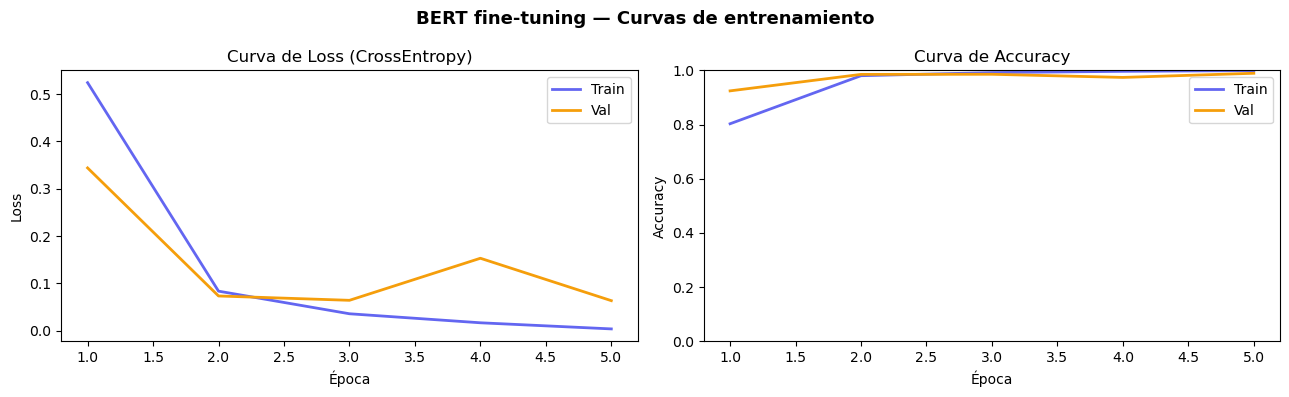

Gap train-val accuracy: 0.0099
→ Sin overfitting significativo


In [32]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='#6366f1', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='#f59e0b', linewidth=2)
axes[0].set_title('Curva de Loss (CrossEntropy)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train', color='#6366f1', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   label='Val',   color='#f59e0b', linewidth=2)
axes[1].set_title('Curva de Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('BERT fine-tuning — Curvas de entrenamiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f'Gap train-val accuracy: {gap:.4f}')
print('→ ' + ('Posible overfitting' if gap > 0.05 else 'Sin overfitting significativo'))

---
## 8. Evaluación sobre Test

In [33]:
# Cargar mejor modelo
model = BertForSequenceClassification.from_pretrained(best_model_path).to(DEVICE)

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch['token_type_ids'].to(DEVICE)
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        ).logits
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(batch['labels'].numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(model, test_loader)
bert_acc = accuracy_score(y_true, y_pred)

print(f'Accuracy en test (BERT fine-tuned): {bert_acc:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9983.72it/s]


Accuracy en test (BERT fine-tuned): 0.9297

                 precision    recall  f1-score   support

   GPT-4.1-nano       0.97      0.82      0.89       315
Gemini-2.5-lite       0.99      0.96      0.97       316
    Grok-3-mini       1.00      0.94      0.97       317
   Llama-3.2-1b       0.83      0.98      0.90       314
   Mixtral-8x7b       0.89      0.95      0.92       317

       accuracy                           0.93      1579
      macro avg       0.94      0.93      0.93      1579
   weighted avg       0.94      0.93      0.93      1579



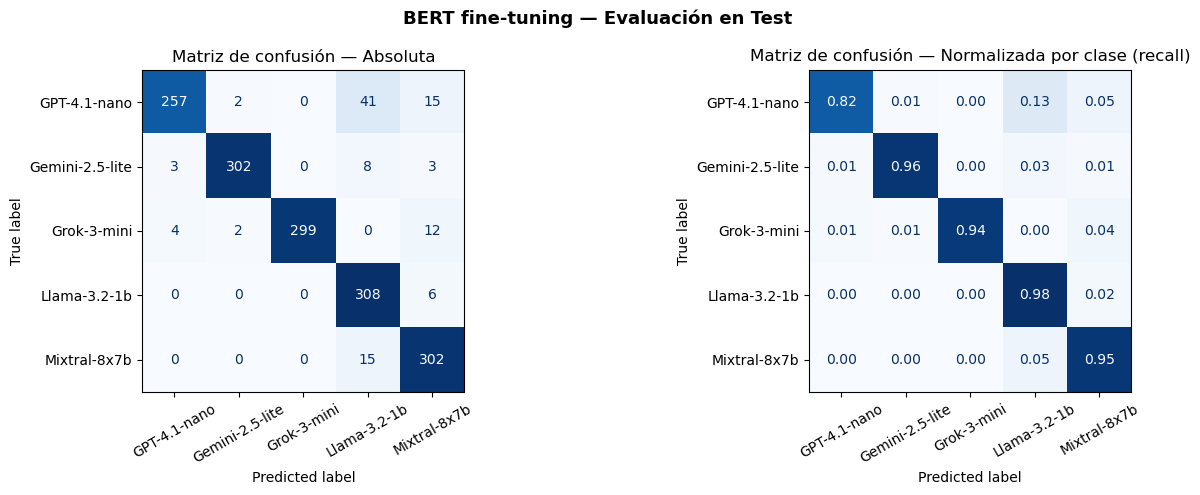

In [34]:
# ── Matriz de confusión ────────────────────────────────────────────────────
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Absoluta', 'Normalizada por clase (recall)']
):
    ConfusionMatrixDisplay(data, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format=fmt
    )
    ax.set_title(f'Matriz de confusión — {title}')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('BERT fine-tuning — Evaluación en Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
def predict_author(text, model, tokenizer, device, max_len=512):
    model.eval()
    
    # 1. Tokenización
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    
    # 2. Mover a GPU
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # 3. Inferencia
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        prediction_idx = torch.argmax(probs, dim=1).item()
        confidence = torch.max(probs).item()
    
    # 4. MAPEO CRÍTICO
    # Diccionario que me pasaste
    MODEL_SHORT = {
        'x-ai/grok-3-mini': 'Grok-3-mini',
        'openai/gpt-4.1-nano': 'GPT-4.1-nano',
        'mistralai/mixtral-8x7b-instruct': 'Mixtral-8x7b',
        'meta-llama/llama-3.2-1b-instruct': 'Llama-3.2-1b',
        'google/gemini-2.5-flash-lite': 'Gemini-2.5-lite',
    }
    
    try:
        # Obtenemos el nombre largo del label_encoder (ej: 'google/gemini...')
        nombre_largo = label_encoder.inverse_transform([prediction_idx])[0]
        # Lo traducimos a tu nombre corto (ej: 'Gemini-2.5-lite')
        autor = MODEL_SHORT.get(nombre_largo, nombre_largo)
    except:
        # Si por algo falla el label_encoder, intentamos sacarlo por orden alfabético 
        # (que es como suele ordenar LabelEncoder por defecto)
        clases_ordenadas = sorted(MODEL_SHORT.keys())
        nombre_largo = clases_ordenadas[prediction_idx]
        autor = MODEL_SHORT[nombre_largo]
    
    return autor, confidence

# --- PRUEBA ---
texto_input = input("Pega el texto: ")
autor, conf = predict_author(texto_input, model, tokenizer, DEVICE, MAX_LEN)

print(f"\nAutor detectado: {autor}")
print(f"Confianza: {conf:.2%}")


Autor detectado: Llama-3.2-1b
Confianza: 92.86%
